# Manual Detection Shapefiles: Coverage & Training Gaps

Explores the manual detection shapefiles and track labels to assess:
1. Spatial & temporal coverage
2. Label distribution & class balance
3. Debris shape characteristics
4. Gaps that could hurt XGBoost track classifier or CNN debris classifier training

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import json
import glob
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import Counter
from pathlib import Path

MANUAL_DIR = Path('/Users/zmhoppinen/Documents/sarvalanche/local/manual_detections/issw')
ISSW_DIR = Path('/Users/zmhoppinen/Documents/sarvalanche/local/issw')
LABELS_PATH = ISSW_DIR / 'track_labels.json'
DEBRIS_GPKG = ISSW_DIR / 'debris_shapes.gpkg'

# Short zone names for plotting
ZONE_SHORT = {
    'Banner_Summit': 'Banner',
    'Galena_Summit_&_Eastern_Mtns': 'Galena',
    'Sawtooth_&_Western_Smoky_Mtns': 'Sawtooth',
    'Soldier_&_Wood_River_Valley_Mtns': 'Soldier',
}

## 1. Load all data sources

In [2]:
# Load hand-drawn shapefiles (raw polygons, no track association)
shapefiles = {}
for shp in sorted(MANUAL_DIR.glob('*.shp')):
    date = shp.stem
    gdf = gpd.read_file(shp)
    gdf['date'] = date
    # Reproject to UTM for area calculations
    gdf_utm = gdf.to_crs('EPSG:32611')
    gdf['area_m2'] = gdf_utm.geometry.area
    shapefiles[date] = gdf
    
raw_shapes = pd.concat(shapefiles.values(), ignore_index=True)
print(f'Raw hand-drawn shapes: {len(raw_shapes)} across {len(shapefiles)} dates')

# Load track-associated debris shapes
debris = gpd.read_file(DEBRIS_GPKG)
print(f'Track-associated debris shapes: {len(debris)} ({debris["key"].nunique()} unique tracks)')

# Load track labels
with open(LABELS_PATH) as f:
    labels_raw = json.load(f)
labels = pd.DataFrame(labels_raw.values())
labels['label_binary'] = (labels['label'] >= 2).astype(int)
print(f'Track labels: {len(labels)} total')

Raw hand-drawn shapes: 1128 across 8 dates
Track-associated debris shapes: 2363 (1856 unique tracks)
Track labels: 2694 total


## 2. Temporal coverage

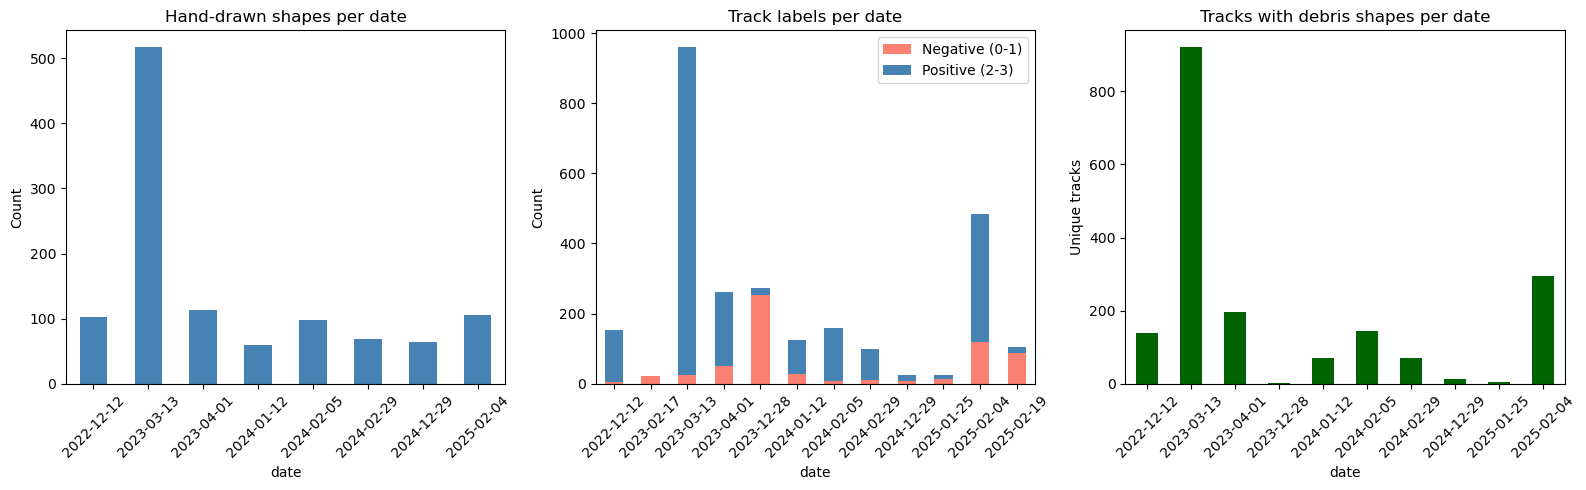

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Raw shapes per date ---
ax = axes[0]
raw_counts = raw_shapes.groupby('date').size()
raw_counts.plot.bar(ax=ax, color='steelblue')
ax.set_title('Hand-drawn shapes per date')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

# --- Track labels per date ---
ax = axes[1]
date_label_counts = labels.groupby(['date', 'label_binary']).size().unstack(fill_value=0)
date_label_counts.columns = ['Negative (0-1)', 'Positive (2-3)']
date_label_counts.plot.bar(stacked=True, ax=ax, color=['salmon', 'steelblue'])
ax.set_title('Track labels per date')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right')

# --- Debris shapes per date ---
ax = axes[2]
debris_date_counts = debris.groupby('date')['key'].nunique()
debris_date_counts.plot.bar(ax=ax, color='darkgreen')
ax.set_title('Tracks with debris shapes per date')
ax.set_ylabel('Unique tracks')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Zone coverage

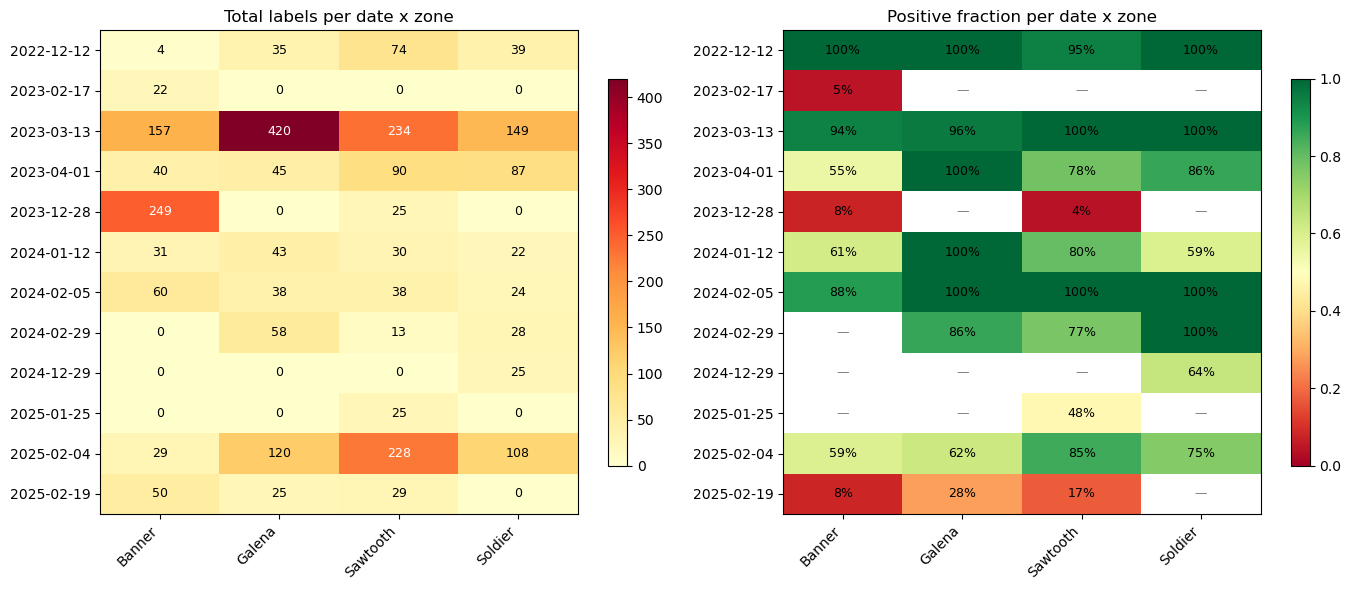

In [4]:
# Date x Zone heatmap of label counts
cross = labels.groupby(['date', 'zone']).size().unstack(fill_value=0)
cross.columns = [ZONE_SHORT.get(c, c) for c in cross.columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Total labels
ax = axes[0]
im = ax.imshow(cross.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(cross.columns)))
ax.set_xticklabels(cross.columns, rotation=45, ha='right')
ax.set_yticks(range(len(cross.index)))
ax.set_yticklabels(cross.index)
for i in range(len(cross.index)):
    for j in range(len(cross.columns)):
        val = cross.values[i, j]
        ax.text(j, i, str(val), ha='center', va='center',
                color='white' if val > cross.values.max()/2 else 'black', fontsize=9)
ax.set_title('Total labels per date x zone')
plt.colorbar(im, ax=ax, shrink=0.8)

# Positive fraction
pos_cross = labels[labels['label_binary']==1].groupby(['date', 'zone']).size().unstack(fill_value=0)
pos_cross.columns = [ZONE_SHORT.get(c, c) for c in pos_cross.columns]
# Align indices
pos_cross = pos_cross.reindex(index=cross.index, columns=cross.columns, fill_value=0)
frac = pos_cross / cross.replace(0, np.nan)

ax = axes[1]
im = ax.imshow(frac.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(frac.columns)))
ax.set_xticklabels(frac.columns, rotation=45, ha='right')
ax.set_yticks(range(len(frac.index)))
ax.set_yticklabels(frac.index)
for i in range(len(frac.index)):
    for j in range(len(frac.columns)):
        val = frac.values[i, j]
        total = cross.values[i, j]
        if total > 0:
            ax.text(j, i, f'{val:.0%}', ha='center', va='center', fontsize=9)
        else:
            ax.text(j, i, '—', ha='center', va='center', color='gray', fontsize=9)
ax.set_title('Positive fraction per date x zone')
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

## 4. Label distribution & class balance

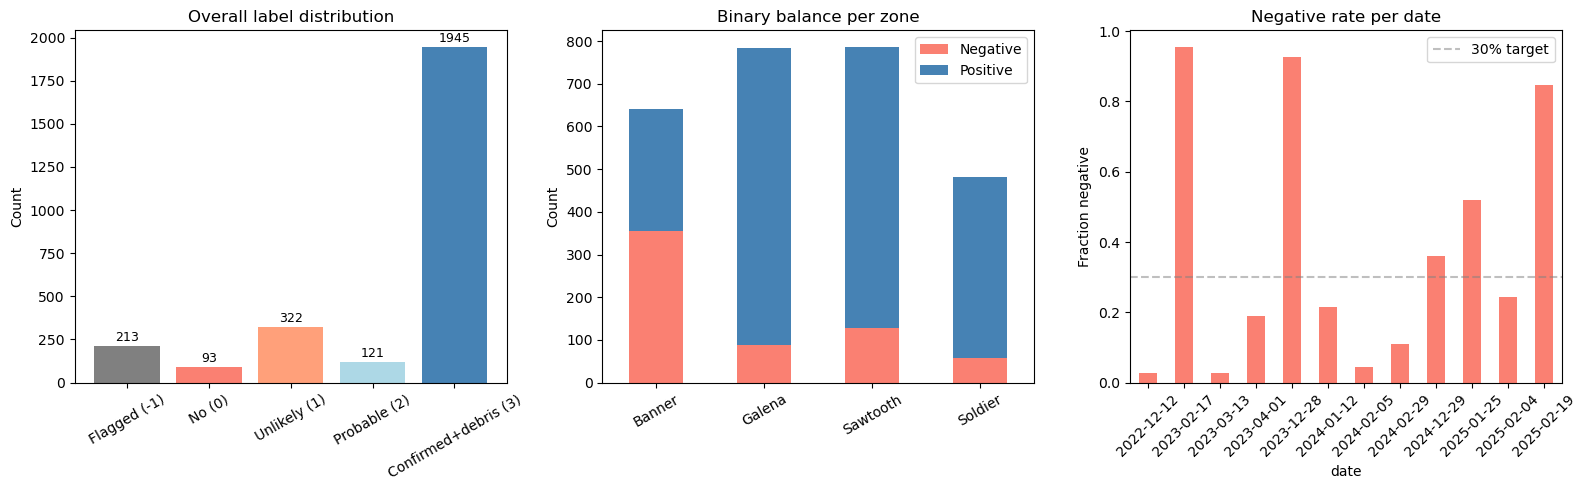

In [5]:
label_map = {-1: 'Flagged (-1)', 0: 'No (0)', 1: 'Unlikely (1)', 2: 'Probable (2)', 3: 'Confirmed+debris (3)'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall distribution
ax = axes[0]
counts = labels['label'].value_counts().sort_index()
colors = ['gray', 'salmon', 'lightsalmon', 'lightblue', 'steelblue']
bars = ax.bar([label_map.get(i, str(i)) for i in counts.index], counts.values, color=colors)
ax.set_title('Overall label distribution')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val),
            ha='center', va='bottom', fontsize=9)

# Binary balance per zone
ax = axes[1]
zone_binary = labels.groupby(['zone', 'label_binary']).size().unstack(fill_value=0)
zone_binary.columns = ['Negative', 'Positive']
zone_binary.index = [ZONE_SHORT.get(z, z) for z in zone_binary.index]
zone_binary.plot.bar(stacked=True, ax=ax, color=['salmon', 'steelblue'])
ax.set_title('Binary balance per zone')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)

# Negative rate per date
ax = axes[2]
date_binary = labels.groupby(['date', 'label_binary']).size().unstack(fill_value=0)
date_binary.columns = ['Negative', 'Positive']
neg_rate = date_binary['Negative'] / date_binary.sum(axis=1)
neg_rate.plot.bar(ax=ax, color='salmon')
ax.set_title('Negative rate per date')
ax.set_ylabel('Fraction negative')
ax.axhline(0.3, color='gray', linestyle='--', alpha=0.5, label='30% target')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Debris shape characteristics

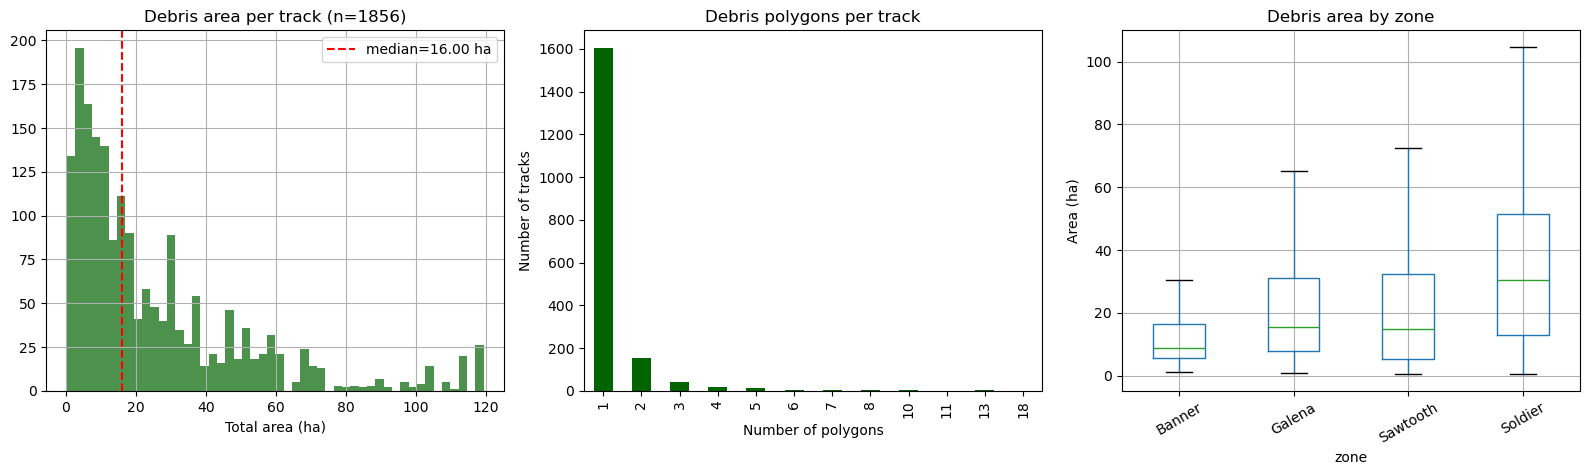

In [6]:
# Compute area of debris shapes
debris['area_m2'] = debris.geometry.area  # already in UTM
debris['area_ha'] = debris['area_m2'] / 1e4

# Group by track (multiple debris polygons per track)
track_debris = debris.groupby('key').agg(
    total_area_m2=('area_m2', 'sum'),
    n_polygons=('area_m2', 'count'),
    zone=('zone', 'first'),
    date=('date', 'first'),
).reset_index()
track_debris['total_area_ha'] = track_debris['total_area_m2'] / 1e4

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Area distribution
ax = axes[0]
track_debris['total_area_ha'].clip(upper=track_debris['total_area_ha'].quantile(0.99)).hist(
    bins=50, ax=ax, color='darkgreen', alpha=0.7)
ax.set_title(f'Debris area per track (n={len(track_debris)})')
ax.set_xlabel('Total area (ha)')
ax.axvline(track_debris['total_area_ha'].median(), color='red', linestyle='--',
           label=f'median={track_debris["total_area_ha"].median():.2f} ha')
ax.legend()

# Polygons per track
ax = axes[1]
track_debris['n_polygons'].value_counts().sort_index().head(15).plot.bar(ax=ax, color='darkgreen')
ax.set_title('Debris polygons per track')
ax.set_xlabel('Number of polygons')
ax.set_ylabel('Number of tracks')

# Area by zone
ax = axes[2]
track_debris.boxplot(column='total_area_ha', by='zone', ax=ax, showfliers=False)
ax.set_xticklabels([ZONE_SHORT.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()], rotation=30)
ax.set_title('Debris area by zone')
ax.set_ylabel('Area (ha)')
ax.get_figure().suptitle('')

plt.tight_layout()
plt.show()

## 6. Spatial coverage of hand-drawn shapes

/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_15655/3042583270.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid
/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_15655/3042583270.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid
/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_15655/3042583270.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid
/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_15655/3042583270.py:8: UserWarni

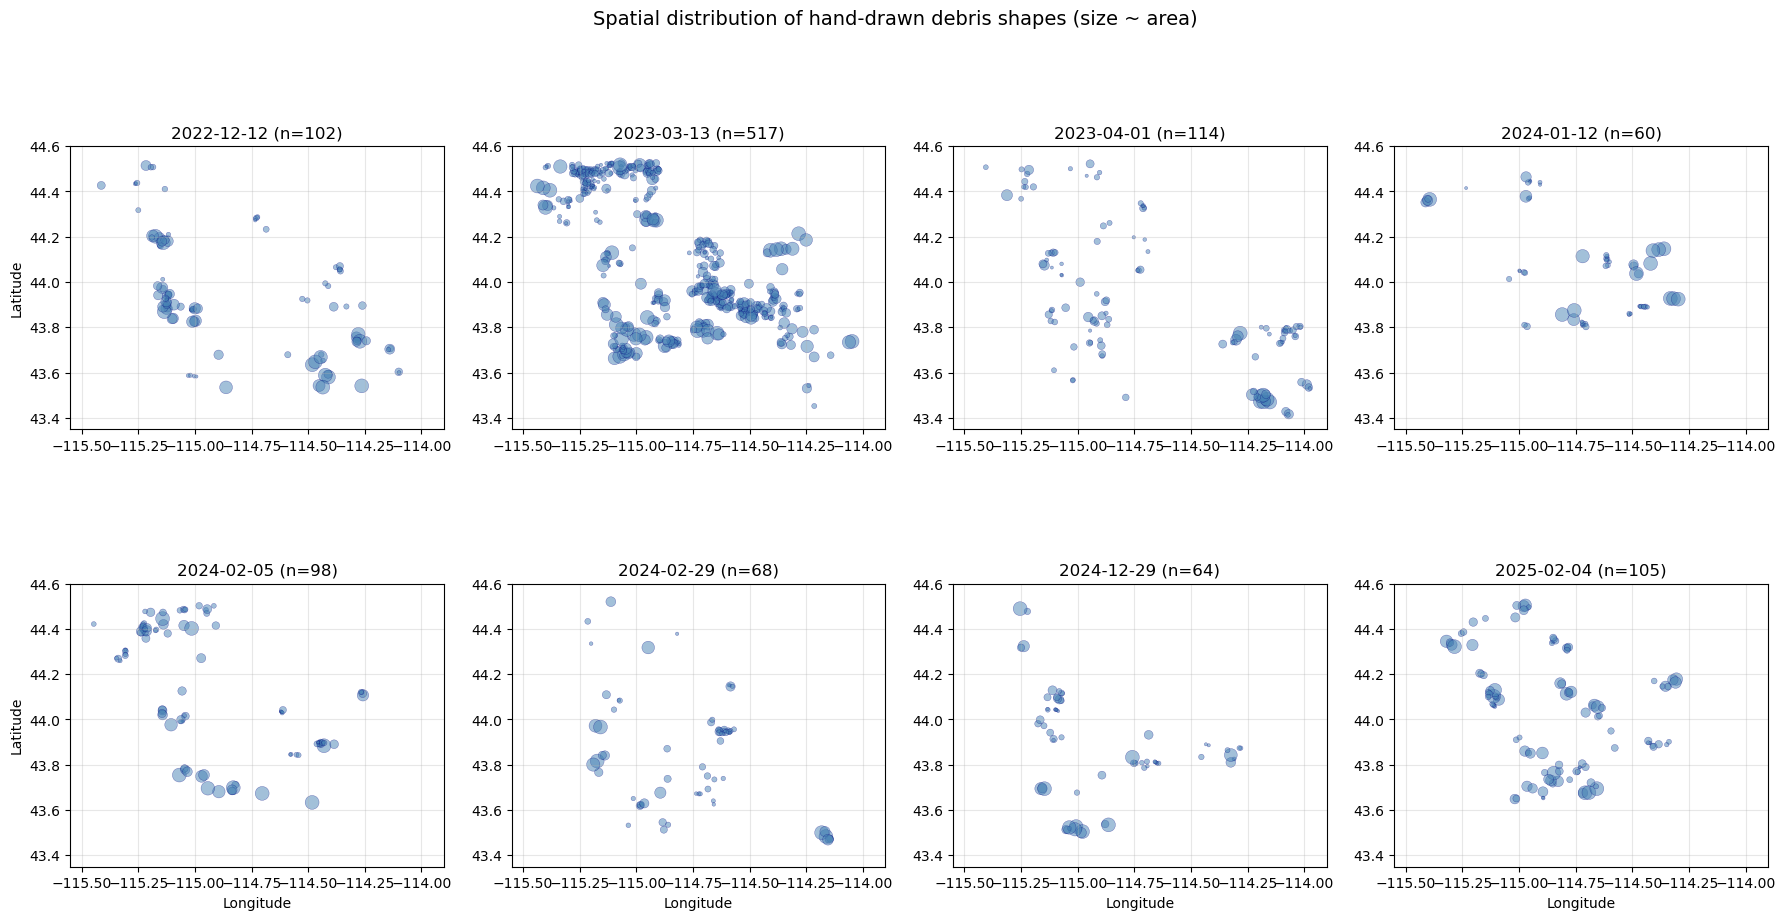

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

dates = sorted(shapefiles.keys())
for i, date in enumerate(dates):
    ax = axes[i]
    gdf = shapefiles[date]
    centroids = gdf.geometry.centroid
    ax.scatter(centroids.x, centroids.y, s=np.clip(gdf['area_m2']/5000, 5, 100),
               alpha=0.5, c='steelblue', edgecolors='navy', linewidths=0.3)
    ax.set_title(f'{date} (n={len(gdf)})')
    ax.set_xlim(-115.55, -113.9)
    ax.set_ylim(43.35, 44.6)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    if i % 4 == 0:
        ax.set_ylabel('Latitude')
    if i >= 4:
        ax.set_xlabel('Longitude')

plt.suptitle('Spatial distribution of hand-drawn debris shapes (size ~ area)', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Raw shapes vs track-associated debris shapes

In [8]:
# Compare counts: raw hand-drawn vs track-joined debris shapes vs track labels
comparison = pd.DataFrame({
    'raw_shapes': raw_shapes.groupby('date').size(),
    'debris_tracks': debris.groupby('date')['key'].nunique(),
    'labeled_positive': labels[labels['label_binary']==1].groupby('date').size(),
    'labeled_negative': labels[labels['label_binary']==0].groupby('date').size(),
    'flagged': labels[labels['label']==-1].groupby('date').size(),
}).fillna(0).astype(int)

comparison['labeled_total'] = comparison['labeled_positive'] + comparison['labeled_negative'] + comparison['flagged']
comparison['pos_with_debris_frac'] = (comparison['debris_tracks'] / comparison['labeled_positive'].replace(0, np.nan)).round(2)

print('=== Coverage comparison per date ===')
print(comparison.to_string())
print()
print(f'Dates with raw shapes but no track labels: '
      f'{set(raw_shapes["date"].unique()) - set(labels["date"].unique())}')
print(f'Dates with track labels but no raw shapes: '
      f'{set(labels["date"].unique()) - set(raw_shapes["date"].unique())}')

=== Coverage comparison per date ===
            raw_shapes  debris_tracks  labeled_positive  labeled_negative  flagged  labeled_total  pos_with_debris_frac
date                                                                                                                   
2022-12-12         102            140               148                 4        0            152                  0.95
2023-02-17           0              0                 1                21        8             30                  0.00
2023-03-13         517            921               934                26        4            964                  0.99
2023-04-01         114            197               212                50       13            275                  0.93
2023-12-28           0              2                20               254       93            367                  0.10
2024-01-12          60             70                99                27        3            129                  0.71
202

## 8. Gap analysis for training

In [9]:
print('=' * 80)
print('GAP ANALYSIS: Issues that could hurt XGBoost track classifier & CNN debris classifier')
print('=' * 80)

# --- Issue 1: Massive class imbalance ---
total_pos = (labels['label_binary'] == 1).sum()
total_neg = (labels['label_binary'] == 0).sum()
total_flag = (labels['label'] == -1).sum()
print(f'\n1. CLASS IMBALANCE')
print(f'   Positive: {total_pos} ({total_pos/len(labels):.1%})')
print(f'   Negative: {total_neg} ({total_neg/len(labels):.1%})')
print(f'   Flagged:  {total_flag} ({total_flag/len(labels):.1%})')
print(f'   Ratio pos:neg = {total_pos/max(total_neg,1):.1f}:1')
print(f'   >> PROBLEM: Very few negatives. XGBoost will see almost all positives.')
print(f'   >> Many dates have 0 negative labels (especially Galena, Soldier zones).')

# --- Issue 2: Temporal dominance ---
date_counts = labels.groupby('date').size()
print(f'\n2. TEMPORAL DOMINANCE')
print(f'   2023-03-13 alone has {date_counts.get("2023-03-13", 0)} labels '
      f'({date_counts.get("2023-03-13", 0)/len(labels):.1%} of all data)')
print(f'   Top 3 dates cover {date_counts.nlargest(3).sum()/len(labels):.1%} of all labels')
print(f'   >> PROBLEM: Model may overfit to conditions on 2023-03-13.')

# --- Issue 3: Missing zone-date combos ---
all_zones = labels['zone'].unique()
all_dates = labels['date'].unique()
missing = []
for d in sorted(all_dates):
    for z in sorted(all_zones):
        mask = (labels['date'] == d) & (labels['zone'] == z)
        if mask.sum() == 0:
            missing.append((d, ZONE_SHORT.get(z, z)))
print(f'\n3. MISSING ZONE-DATE COMBINATIONS ({len(missing)} gaps)')
for d, z in missing:
    print(f'   {d} x {z}')
print(f'   >> PROBLEM: No coverage means model cannot learn zone-specific patterns for these dates.')

# --- Issue 4: Dates with no negatives ---
neg_by_date = labels[labels['label_binary']==0].groupby('date').size()
dates_no_neg = set(all_dates) - set(neg_by_date.index)
print(f'\n4. DATES WITH ZERO NEGATIVE LABELS')
for d in sorted(dates_no_neg):
    n = date_counts[d]
    print(f'   {d}: {n} labels, ALL positive')
print(f'   >> PROBLEM: XGBoost cannot learn false-positive patterns for these dates.')

# --- Issue 5: Seasonal coverage ---
months = pd.to_datetime(labels['date']).dt.month
month_counts = months.value_counts().sort_index()
print(f'\n5. SEASONAL COVERAGE (by month)')
for m, c in month_counts.items():
    print(f'   Month {m:2d}: {c:4d} labels')
print(f'   >> NOTE: No labels from Nov, May, or other shoulder months.')
print(f'   >> Heavy March bias ({month_counts.get(3, 0)} labels).')

# --- Issue 6: CNN debris coverage ---
debris_dates = set(debris['date'].unique())
label_dates = set(labels['date'].unique())
dates_labels_no_debris = label_dates - debris_dates
print(f'\n6. CNN DEBRIS SHAPE COVERAGE')
print(f'   Dates with labels but NO debris shapes: {sorted(dates_labels_no_debris)}')
pos_no_debris = labels[(labels['label_binary']==1) & (~labels['date'].isin(debris_dates))]
print(f'   Positive tracks without debris shapes: {len(pos_no_debris)}')
print(f'   >> PROBLEM: CNN cannot train on positive examples without debris polygons.')

# --- Issue 7: Refreezing contamination ---
print(f'\n7. REFREEZING / BACKGROUND CONTAMINATION')
print(f'   2024-01-12: Known refreezing issues (valley floors, south faces, low elevations).')
print(f'   2024-12-29: Scene-wide background increase, 3-5 dB spikes on lakes.')
print(f'   >> PROBLEM: Labels from these dates may include false positives from refreezing.')
print(f'   >> Consider excluding or down-weighting these dates in training.')

GAP ANALYSIS: Issues that could hurt XGBoost track classifier & CNN debris classifier

1. CLASS IMBALANCE
   Positive: 2066 (76.7%)
   Negative: 628 (23.3%)
   Flagged:  213 (7.9%)
   Ratio pos:neg = 3.3:1
   >> PROBLEM: Very few negatives. XGBoost will see almost all positives.
   >> Many dates have 0 negative labels (especially Galena, Soldier zones).

2. TEMPORAL DOMINANCE
   2023-03-13 alone has 960 labels (35.6% of all data)
   Top 3 dates cover 63.8% of all labels
   >> PROBLEM: Model may overfit to conditions on 2023-03-13.

3. MISSING ZONE-DATE COMBINATIONS (13 gaps)
   2023-02-17 x Galena
   2023-02-17 x Sawtooth
   2023-02-17 x Soldier
   2023-12-28 x Galena
   2023-12-28 x Soldier
   2024-02-29 x Banner
   2024-12-29 x Banner
   2024-12-29 x Galena
   2024-12-29 x Sawtooth
   2025-01-25 x Banner
   2025-01-25 x Galena
   2025-01-25 x Soldier
   2025-02-19 x Soldier
   >> PROBLEM: No coverage means model cannot learn zone-specific patterns for these dates.

4. DATES WITH ZERO

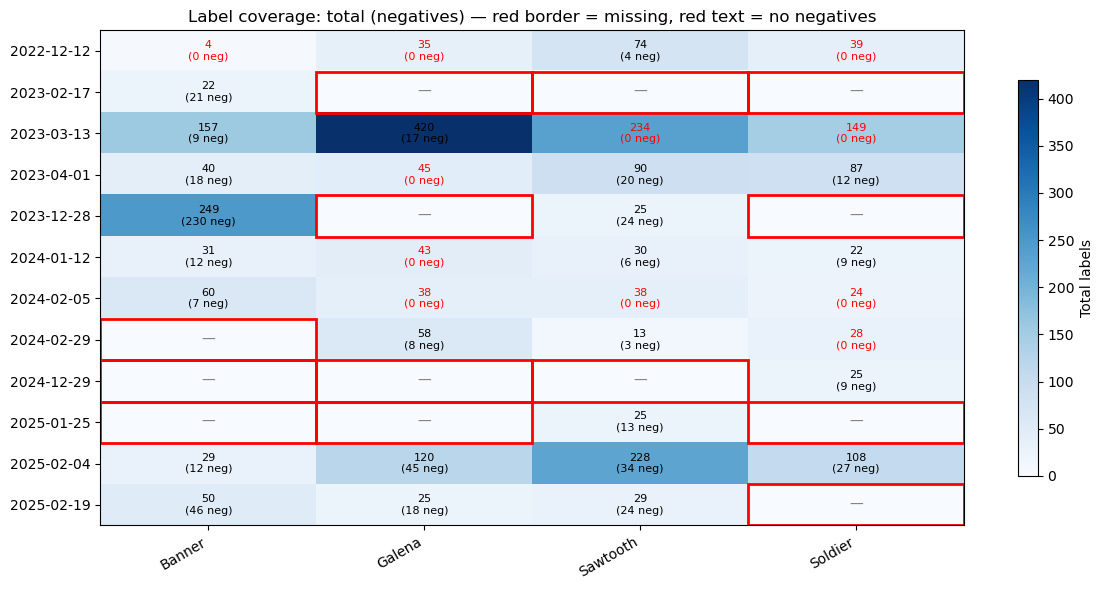

In [10]:
# Summary visualization of gaps
fig, ax = plt.subplots(figsize=(12, 6))

zones_short = [ZONE_SHORT.get(z, z) for z in sorted(all_zones)]
dates_sorted = sorted(all_dates)

grid = np.zeros((len(dates_sorted), len(sorted(all_zones))))
neg_grid = np.zeros_like(grid)

for i, d in enumerate(dates_sorted):
    for j, z in enumerate(sorted(all_zones)):
        mask = (labels['date'] == d) & (labels['zone'] == z)
        grid[i, j] = mask.sum()
        neg_grid[i, j] = ((labels['date'] == d) & (labels['zone'] == z) & (labels['label_binary'] == 0)).sum()

im = ax.imshow(grid, aspect='auto', cmap='Blues')
# Overlay red border for cells with no negatives
for i in range(len(dates_sorted)):
    for j in range(len(zones_short)):
        total = int(grid[i, j])
        neg = int(neg_grid[i, j])
        if total == 0:
            ax.text(j, i, '—', ha='center', va='center', color='gray')
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor='red', linewidth=2))
        elif neg == 0:
            ax.text(j, i, f'{total}\n(0 neg)', ha='center', va='center', fontsize=8, color='red')
        else:
            ax.text(j, i, f'{total}\n({neg} neg)', ha='center', va='center', fontsize=8)

ax.set_xticks(range(len(zones_short)))
ax.set_xticklabels(zones_short, rotation=30, ha='right')
ax.set_yticks(range(len(dates_sorted)))
ax.set_yticklabels(dates_sorted)
ax.set_title('Label coverage: total (negatives) — red border = missing, red text = no negatives')
plt.colorbar(im, ax=ax, label='Total labels', shrink=0.8)
plt.tight_layout()
plt.show()

## 9. Recommendations

### XGBoost track classifier
- **Critical: need more negatives.** Current ratio is ~8.5:1 positive:negative. Most dates/zones have zero negatives. The low-danger runs should help — make sure to label tracks from those as negatives.
- **2023-03-13 dominates** the dataset (~42% of all labels). Consider capping or down-weighting this date during training.
- **Missing zone-date combos** (especially 2024-02-29 Banner, 2024-12-29 for 3 of 4 zones) leave spatial gaps.
- **Refreezing dates** (2024-01-12, 2024-12-29) may poison the classifier with false positive patterns.

### CNN debris classifier  
- **Debris shapes only exist for 10 of 12 labeled dates.** Positive tracks on missing dates can't be used for CNN training.
- **2023-03-13 and 2025-02-04** provide the bulk of debris shapes. Very few shapes for 2023-12-28, 2025-01-25.
- **Refreezing contamination** — debris shapes from 2024-01-12 may include refreezing artifacts rather than real debris. Consider excluding or flagging.
- **Seasonal bias** — heavy March representation, no shoulder-season examples.
- **Consider using flat terrain signal** (valleys, lakes) as a background/refreeze indicator feature for both classifiers.